In [1]:
import os
os.environ['SM_FRAMEWORK'] = 'tf.keras'
import segmentation_models as sm
import cv2

Segmentation Models: using `tf.keras` framework.


In [2]:
# import packages
import numpy as np
import tensorflow as tf
import keras
import rioxarray as rxr
import rasterio
import PIL
import segmentation_models as sm # library uses OpenCV for image augmentation and processing
import pandas as pd
import pathlib 
import os #provides functions for interacting with the operating system
import requests
import sys
from keras.models import * #take everything inside the keras.losses module and drop them into the current workspace.
from keras.layers import *
from keras.optimizers import *
from keras.losses import *
from keras import backend as K
from keras.callbacks import ModelCheckpoint
# !pip install rarfile segmentation-models git+https://github.com/davej23/image-segmentation-keras.git rioxarray
from rarfile import RarFile
from keras_segmentation.models import segnet # library uses OpenCV for image augmentation and processing
from keras.applications import vgg16 #convolutional neural net architecture for image recognition(16 layers)
from sklearn.metrics import *
from tensorflow.keras.preprocessing.image import ImageDataGenerator #easy way to augment images

# ipykernel: a software allows the Notebook to send code to the Python 3.11 engine.



/Users/jessica/Documents/Jessica/MSc_AI4SD/COMP0173/COMP0173_poster_pre/venv/lib/python3.11/site-packages/imageio/core/util.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [10]:
# Specify whether to download data or read in
download = False
base_dir = r"./Amazon Forest Dataset/"

In [11]:
import requests
import os

if download:
    url = 'https://zenodo.org/record/3233081/files/Amazon%20Forest%20Dataset.rar?download=1'
    
    print("Downloading dataset... this may take a moment.")
    with requests.get(url, stream=True) as r:
        r.raise_for_status() # This will catch if the link is broken (404/500)
        with open('data.rar', 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    print("Download complete!")

    # Extraction logic
    if sys.platform != 'darwin':
        from pyunpack import Archive
        Archive('data.rar').extractall('./')
    else:
        # Note: Ensure you have 'unrar' installed on your Mac (brew install unrar)
        from rarfile import RarFile
        with RarFile('data.rar') as rf:
            rf.extractall()

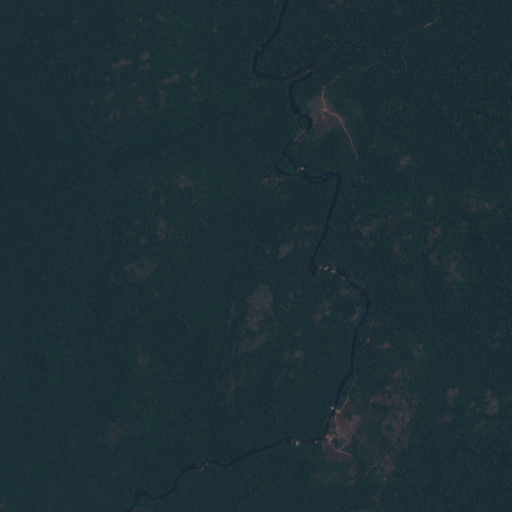

In [14]:
PIL.Image.open(r"{}Training/images/Amazon_1154.tiff_40.tiff".format(base_dir))

In [ ]:
# helper functions
